In [199]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [200]:
import pandas as pd

In [201]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [202]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Inciso a

Estudiar el número de mujeres y hombres en la muestra.


Gender
Male      1068
Female    1043
Name: count, dtype: int64

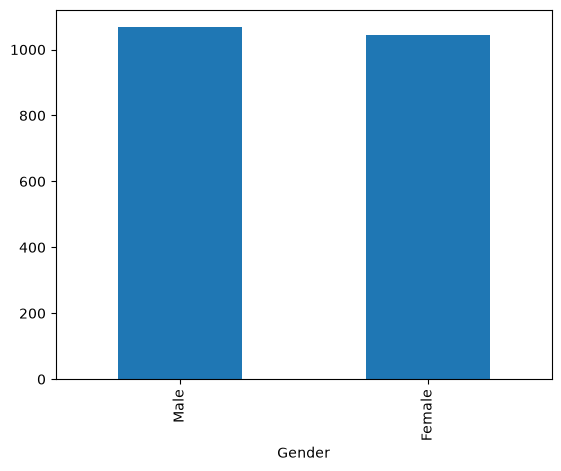

In [203]:
sexo = df['Gender'].value_counts()
sexo.plot(kind='bar')
sexo

Inciso b

Estudiar la proporción de consumidores de alcohol mujeres y hombres.

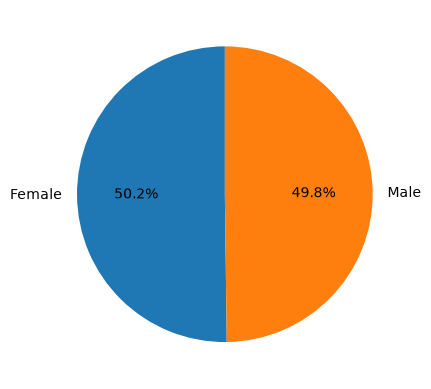

In [204]:
alcohol = df[df['CALC'].isin(['Sometimes', 'Frequently', 'Always'])]['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

Inciso d

Estudiar la relación entre la edad y el peso.

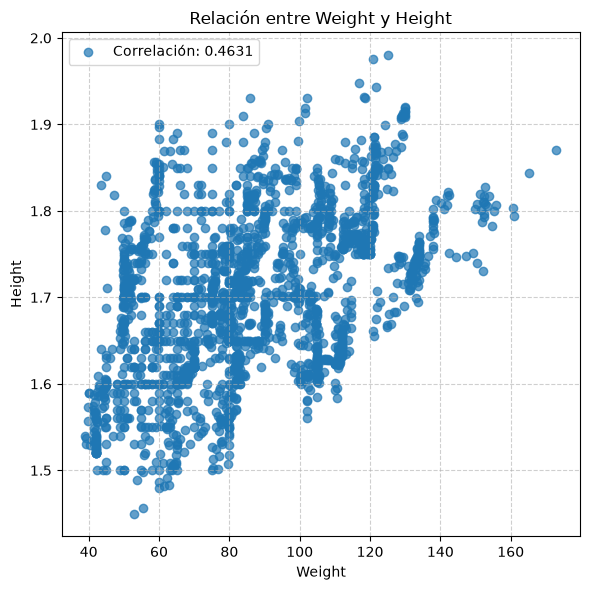

In [205]:
utils.scatter_plot('Weight', 'Height', df)

Podemos ver una relacion (debil) que visibiliza a que mayor peso mayor altura y viceversa.

Inciso c

Estudiar la relación entre la edad y el peso.

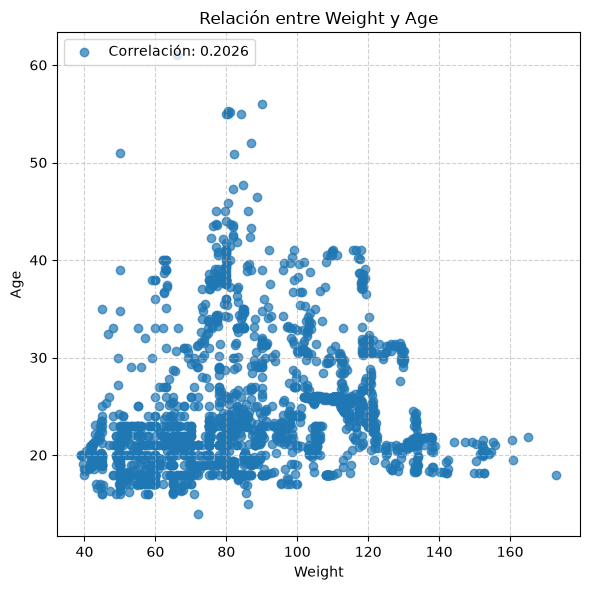

In [206]:
utils.scatter_plot('Weight', 'Age', df)

Podemos ver que no existe relacionan lineal entre la altura y el peso en ningun sentido.

Inciso e

Estudiar la relación entre obesidad y consumo de alcohol.


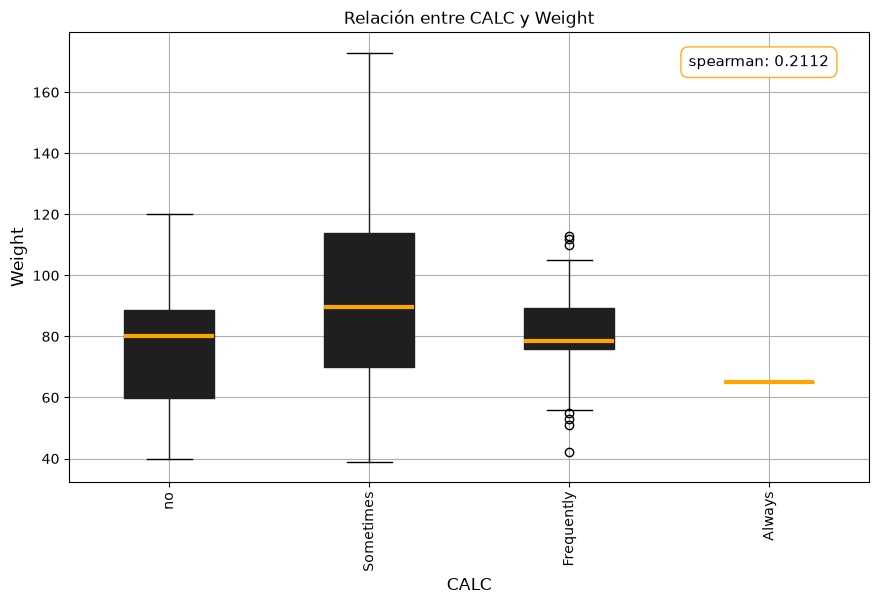

In [207]:
orden = ['no', 'Sometimes', 'Frequently', 'Always']
df['CALC'] = pd.Categorical(
    df['CALC'],
    categories=orden,
    ordered=True
)
utils.box_plot('CALC', 'Weight', df, True)


Podemos ver que no existe relacion fuerte entre mas consumo de alcohol, mayor peso.

Inciso f

Estudiar la proporción de edades en la muestra de mujeres y de hombres. ¿Son similares entre sí? Justificar.


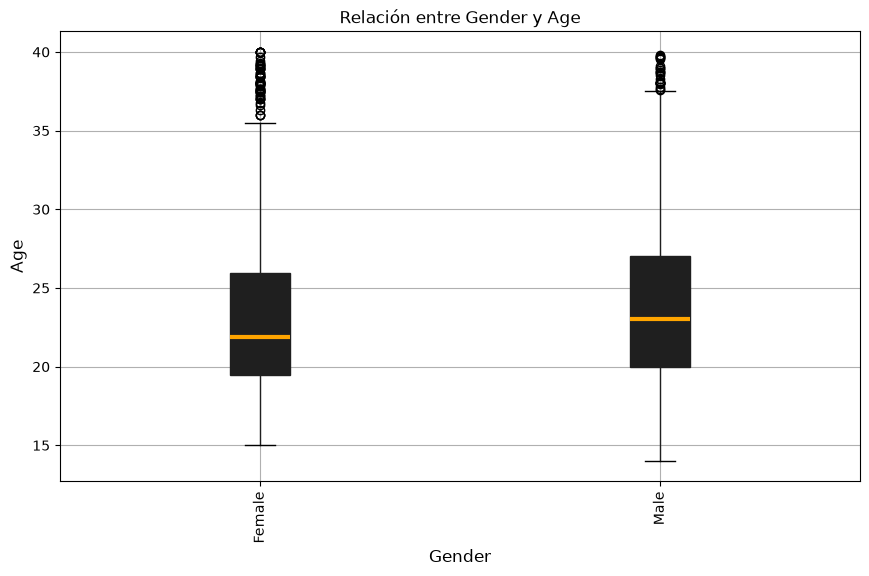

In [208]:
utils.box_plot('Gender', 'Age', df[df['Age'] <= 40])

Podemos ver que la distribucion de edades entre ambos sexos es practicamente igual.

In [209]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Inciso g

Estudiar los valores de peso según la variable categoría de obesidad. ¿Qué puede decirse de ellas?

In [210]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

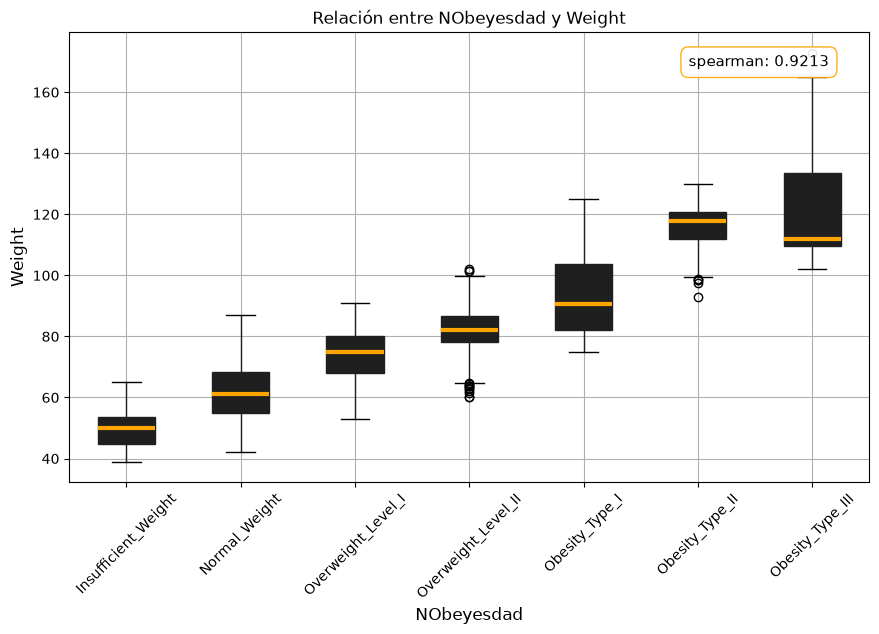

In [211]:
orden = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
df['NObeyesdad'] = pd.Categorical(
    df['NObeyesdad'],
    categories=orden,
    ordered=True
)
utils.box_plot(cuali= 'NObeyesdad', cuanti= 'Weight', df= df, ord= True, rot=45)

Podemos ver claramente una relacion lineal y esto se debe a que la clasificacion de peso viene dado por el indice de masa corporal, calculado a partir del peso y la altura.

Inciso h

Estudiar la relación entre el consumo de vegetales y la obesidad

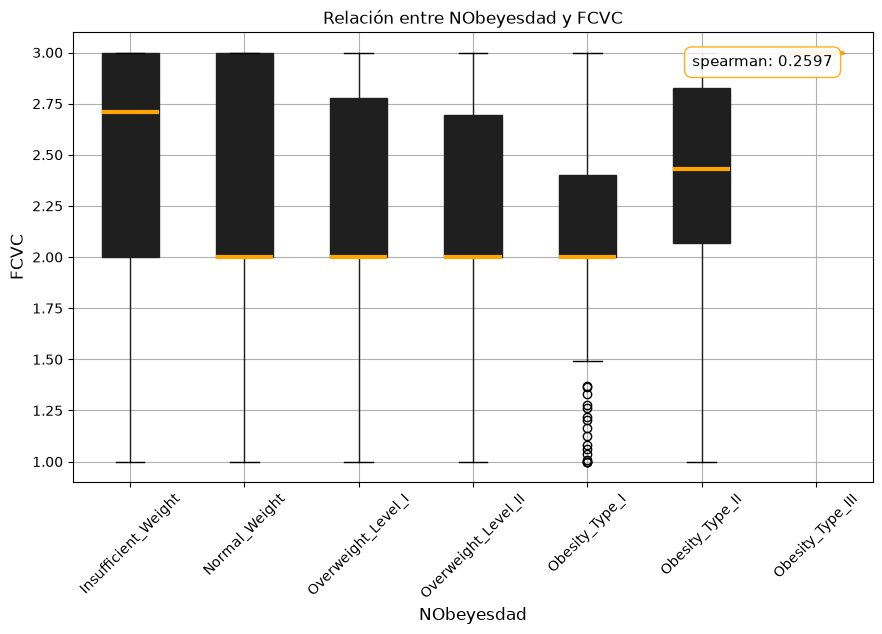

In [212]:
df['FCVC'].value_counts()
utils.box_plot('NObeyesdad', 'FCVC', df, True, 45)

In [239]:
#Limpiamos los valores no enteros
df_f = df
df_f = df[df['FCVC'].apply(lambda x: x % 1 == 0)]

In [242]:
df_f['FCVC'].value_counts()

FCVC
always       652
sometimes    600
never         33
Name: count, dtype: int64

In [241]:
map = {
    1: 'never',
    2: 'sometimes',
    3: 'always'
}
df_f['FCVC'] = df_f['FCVC'].replace(map)

Inciso g

Proponer gráficas adicionales basándose en las sugerencias vistas durante la clase práctica.

In [216]:
from cProfile import label
from matplotlib import pyplot as plt

In [236]:
df_g = df

#normalizamos a vefetales enteros
df_g = df_g[df_g['FCVC'].apply(lambda x: x % 1 == 0)]

#normalizamos a edades enteras
df_g = df_g[df_g['Age'].apply(lambda x: x % 1 == 0)]

df_g_x1 = df_g

#filtramos los que al menos si comen vegetales
df_g = df_g[df_g['FCVC'] >= 2]

In [237]:
age_less_30 = df_g[df_g['Age'] <= 30]
data = age_less_30
#data = df_g

data_x1 = age_less_30_x1
#data_x1 = df_g_x1

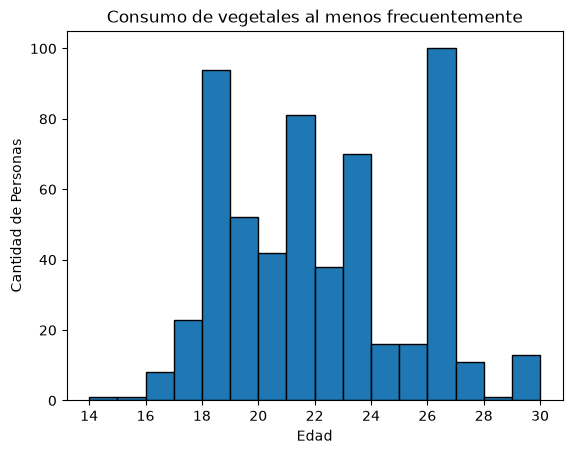

In [230]:
#Recordamos que un histograma nos sirve
#para mostrar la frecuencia de valores para una variable cuanti continua

plt.hist(data['Age'], bins=16, edgecolor='black', label="Personas que comen vegetales")
plt.xlabel('Edad')
plt.ylabel('Cantidad de Personas')
plt.title('Consumo de vegetales al menos frecuentemente')
plt.show()

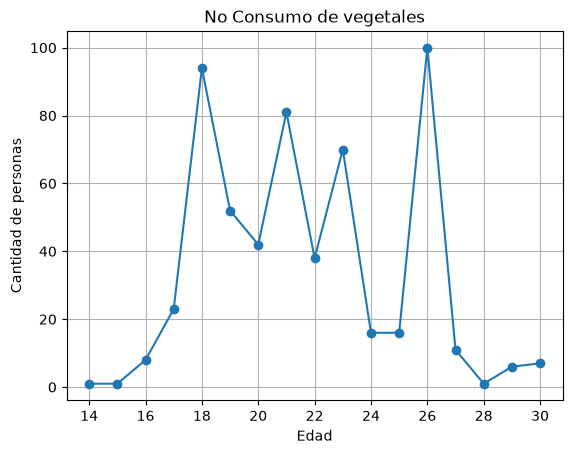

In [238]:
sqy = data['Age'].value_counts().sort_index()
plt.plot(sqy.index, sqy.values, marker='o')
plt.xlabel('Edad')
plt.ylabel('Cantidad de personas')
plt.title('No Consumo de vegetales')
plt.grid(True)
plt.show()


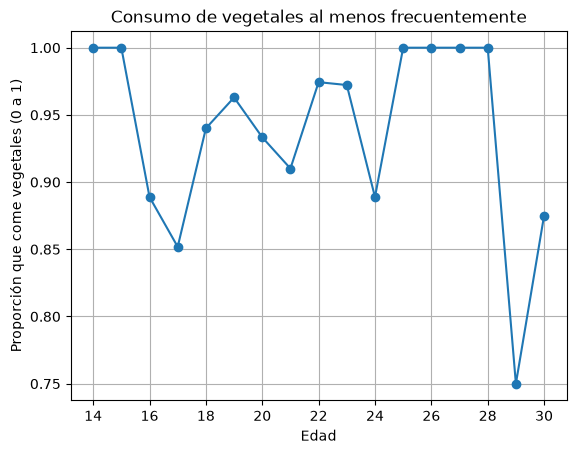

In [232]:
#agrupamos por edad y usamos 0 o 1 si consumen o no vegetales y luego calculamos la media sobre esos
age_less_30_x1 = df_g_x1[df_g_x1['Age'] <= 30]

proporcion_por_edad = (df['FCVC'] >= 2).groupby(data_x1['Age']).mean()

plt.plot(proporcion_por_edad.index, proporcion_por_edad.values, marker='o')
plt.xlabel('Edad')
plt.ylabel('Proporción que come vegetales (0 a 1)')
plt.title('Consumo de vegetales al menos frecuentemente')
plt.grid(True)
plt.show()

Analizamos los graficos a la par.

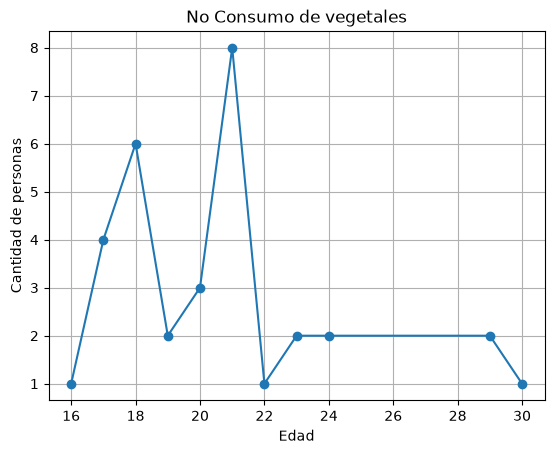
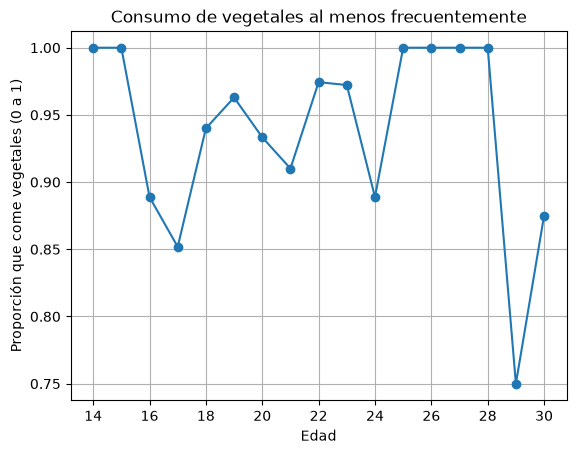
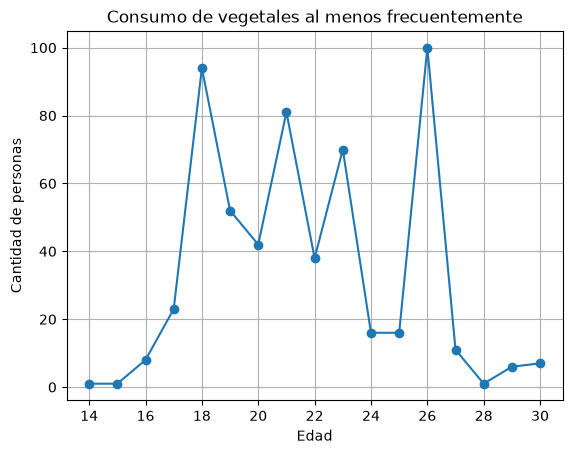
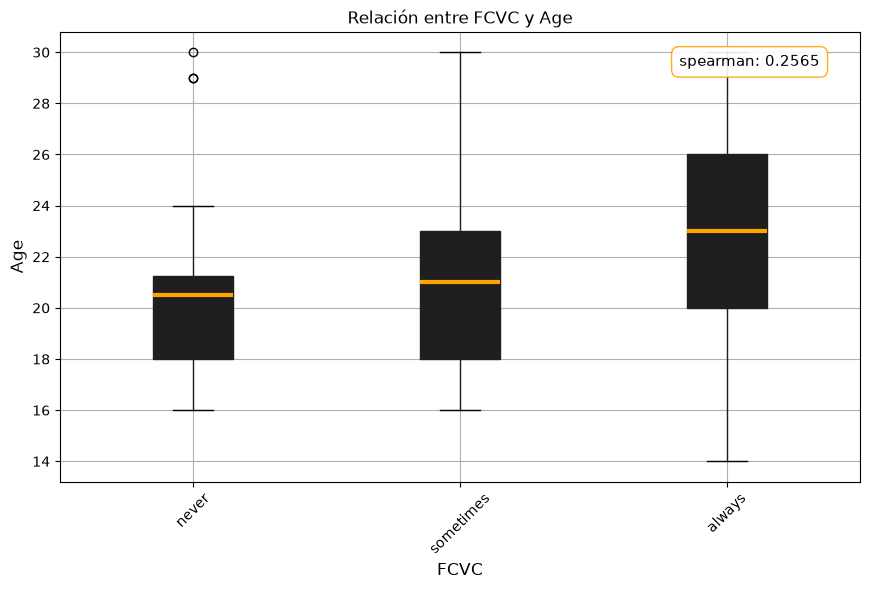

Como valor de negocio, podemos analizar estos datos en busca de edades en las que se debe fortalecer el consumo de vegetales, por ejemplo

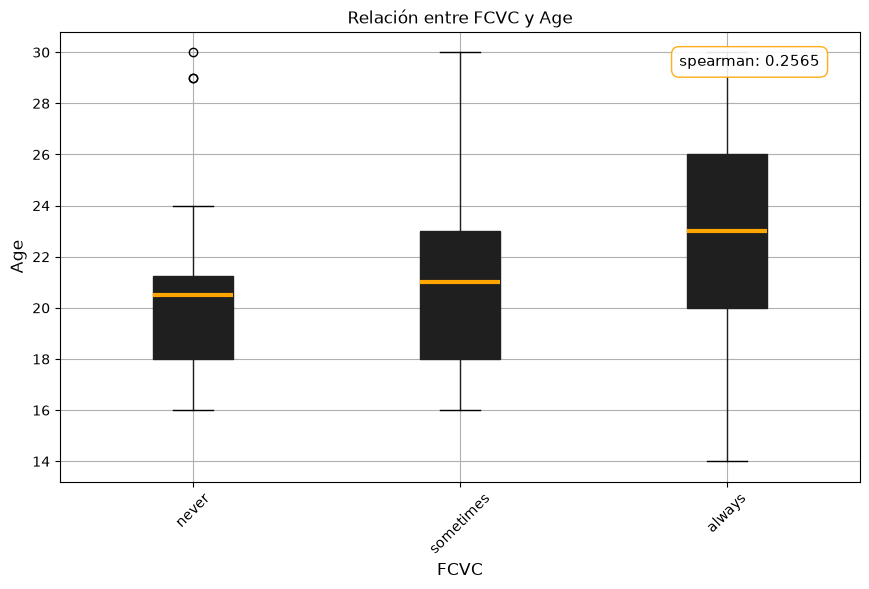

In [259]:
df_g_box = df[df['Age'] <= 30]
df_g_box = df_g_box[(df_g_box['FCVC'].apply(lambda x: x % 1 == 0)) & (df_g_box['Age'].apply(lambda x: x % 1 == 0))]
map = {
    1: 'never',
    2: 'sometimes',
    3: 'always'
}
df_g_box['FCVC'] = df_g_box['FCVC'].replace(map)

orden = ['never', 'sometimes', 'always']
df_g_box['FCVC'] = pd.Categorical(
    df_g_box['FCVC'],
    categories=orden,
    ordered=True
)

utils.box_plot('FCVC', 'Age', df_g_box, True, 45)